# MNIST CNN Training (Standard and Adversarial)



In [1]:

from cnn import Net, MaxoutNet
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_best_device(verbose=True):
    import sys

    if verbose:
        print(f"Python executable: {sys.executable}")
        print(f"PyTorch version: {torch.__version__}")
        print(f"CUDA available: {torch.cuda.is_available()}")

    if torch.cuda.is_available():
        return torch.device("cuda"), "cuda"

    try:
        import torch_directml
        dml_device = torch_directml.device()
        if verbose:
            print("DirectML available: True")
        return dml_device, "directml"
    except Exception as e:
        if verbose:
            print(f"DirectML available: False ({e})")
        return torch.device("cpu"), "cpu"


def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().requires_grad_(True)
    outputs = model(images)
    loss = torch.nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    grad = torch.autograd.grad(loss, images, only_inputs=True)[0]
    sign_grad = grad.sign()
    adv_images = images + epsilon * sign_grad

    mean = 0.1307
    std = 0.3081
    min_val = (0 - mean) / std
    max_val = (1 - mean) / std
    adv_images = torch.clamp(adv_images, min_val, max_val)

    return adv_images.detach()


def evaluate_fgsm(model, dataloader, device, epsilon):
    model.eval()
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        adv_images = fgsm_attack(model, images, labels, epsilon)

        outputs = model(adv_images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [ ]:

EPSILONS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

def train(net, adversarial_training=False, alpha=0.5, epsilon_training=0.25, num_epochs=5, lr=0.001):
    set_seed(42)

    device, backend = get_best_device()
    print(f"Device: {device} ({backend})")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    net = net.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)

    loss_history = []
    clean_acc_history = []
    fgsm_acc_history = []

    print(f"{'Adversarial' if adversarial_training else 'Standard'} Training Started")
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = net(images)
            loss = criterion(outputs, labels)

            total_loss = loss
            if adversarial_training:
                adv_images = fgsm_attack(net, images, labels, epsilon=epsilon_training)
                adv_outputs = net(adv_images)
                adv_loss = criterion(adv_outputs, labels)
                total_loss = alpha * loss + (1 - alpha) * adv_loss

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

        avg_loss = running_loss / len(train_loader)
        test_acc = evaluate(net, test_loader, device)
        
        loss_history.append(avg_loss)
        clean_acc_history.append(test_acc * 100)
      

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Test Acc: {test_acc*100:.2f}%")
      
    print("Test with adversarial examples:")
    for epsilon in EPSILONS:
        test_acc_fgsm = evaluate_fgsm(net, test_loader, device, epsilon)
        fgsm_acc_history.append(test_acc_fgsm * 100)
        print(f"Epsilon: {epsilon:.2f} | FGSM Test Acc: {test_acc_fgsm*100:.2f}%")

    return {
        "loss_history": loss_history,
        "clean_acc_history": clean_acc_history,
        "fgsm_acc_history": fgsm_acc_history,
        "epsilons": EPSILONS
    }


def plot_standard_training(results):
    plt.figure(figsize=(8, 5))
    plt.plot(EPSILONS, results["fgsm_acc_history"], marker="o", linewidth=2, label="FGSM Test Acc")
    plt.axhline(
        y=results["clean_acc_history"][-1],
        color="r",
        linestyle="--",
        label="Clean Test Acc"
    )
    plt.title("Standard Training: Accuracy vs Epsilon")
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy (%)")
    plt.xticks(EPSILONS)
    plt.grid()
    plt.legend()
    plt.show()

def plot_adversarial_training(standard_results, adversarial_results):
    plt.figure(figsize=(8, 5))
    plt.plot(EPSILONS, standard_results["fgsm_acc_history"], marker="o", linewidth=2, label="Baseline (Standard Training)")
    plt.plot(EPSILONS, adversarial_results["fgsm_acc_history"], marker="o", linewidth=2, label="Adversarial Training")
    plt.axhline(
        y=standard_results["clean_acc_history"][-1],
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        label=f"Baseline Clean Acc ({standard_results['clean_acc_history'][-1]:.2f}%)"
    )
    plt.axhline(
        y=adversarial_results["clean_acc_history"][-1],
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        label=f"Adversarial Clean Acc ({adversarial_results['clean_acc_history'][-1]:.2f}%)"
    )
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy (%)")
    plt.title("Baseline vs Adversarial Accuracy vs Epsilon")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()
    

## Test with ReLU network

Standard training

Python executable: d:\UofW\CS679\project\.venv\Scripts\python.exe
PyTorch version: 2.4.1+cpu
CUDA available: False
DirectML available: True
Device: privateuseone:0 (directml)
Standard Training Started
Epoch 1/15 | Loss: 0.2514 | Test Acc: 97.69%
Epoch 2/15 | Loss: 0.0693 | Test Acc: 98.50%
Epoch 3/15 | Loss: 0.0522 | Test Acc: 98.52%
Epoch 4/15 | Loss: 0.0414 | Test Acc: 98.48%
Epoch 5/15 | Loss: 0.0355 | Test Acc: 98.51%
Epoch 6/15 | Loss: 0.0294 | Test Acc: 98.97%
Epoch 7/15 | Loss: 0.0245 | Test Acc: 98.78%
Epoch 8/15 | Loss: 0.0218 | Test Acc: 99.12%
Epoch 9/15 | Loss: 0.0207 | Test Acc: 98.85%
Epoch 10/15 | Loss: 0.0176 | Test Acc: 98.99%
Epoch 11/15 | Loss: 0.0145 | Test Acc: 98.64%
Epoch 12/15 | Loss: 0.0145 | Test Acc: 99.05%
Epoch 13/15 | Loss: 0.0139 | Test Acc: 99.00%
Epoch 14/15 | Loss: 0.0129 | Test Acc: 99.03%
Epoch 15/15 | Loss: 0.0105 | Test Acc: 99.03%
Test with adversarial examples:
Epsilon: 0.00 | FGSM Test Acc: 99.03%
Epsilon: 0.05 | FGSM Test Acc: 97.83%
Epsilon: 0

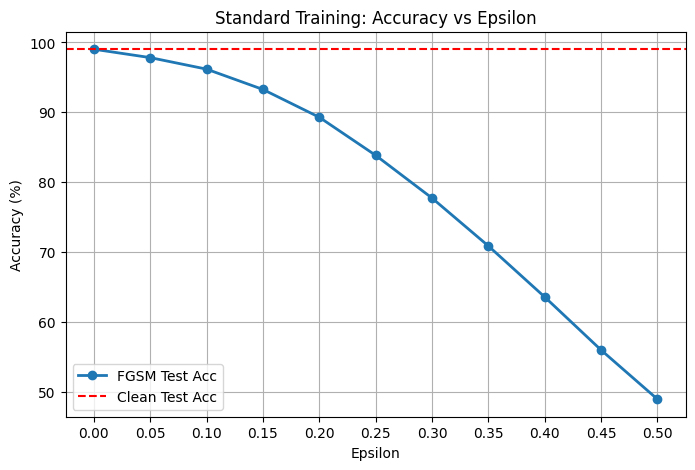

In [16]:
# Run standard training
net = Net()
standard_results = train(net, adversarial_training=False, alpha=0.5, epsilon_training=0.25, num_epochs=15, lr=0.001)
plot_standard_training(standard_results)


Adversarial training

Python executable: d:\UofW\CS679\project\.venv\Scripts\python.exe
PyTorch version: 2.4.1+cpu
CUDA available: False
DirectML available: True
Device: privateuseone:0 (directml)
Adversarial Training Started
Epoch 1/15 | Loss: 0.3813 | Test Acc: 98.23%
Epoch 2/15 | Loss: 0.1386 | Test Acc: 98.63%
Epoch 3/15 | Loss: 0.1076 | Test Acc: 98.92%
Epoch 4/15 | Loss: 0.0900 | Test Acc: 98.99%
Epoch 5/15 | Loss: 0.0791 | Test Acc: 99.09%
Epoch 6/15 | Loss: 0.0712 | Test Acc: 98.96%
Epoch 7/15 | Loss: 0.0639 | Test Acc: 99.14%
Epoch 8/15 | Loss: 0.0584 | Test Acc: 99.23%
Epoch 9/15 | Loss: 0.0540 | Test Acc: 99.21%
Epoch 10/15 | Loss: 0.0506 | Test Acc: 99.21%
Epoch 11/15 | Loss: 0.0475 | Test Acc: 99.25%
Epoch 12/15 | Loss: 0.0446 | Test Acc: 99.27%
Epoch 13/15 | Loss: 0.0433 | Test Acc: 99.23%
Epoch 14/15 | Loss: 0.0401 | Test Acc: 99.30%
Epoch 15/15 | Loss: 0.0384 | Test Acc: 99.20%
Test with adversarial examples:
Epsilon: 0.00 | FGSM Test Acc: 99.20%
Epsilon: 0.05 | FGSM Test Acc: 98.91%
Epsilon

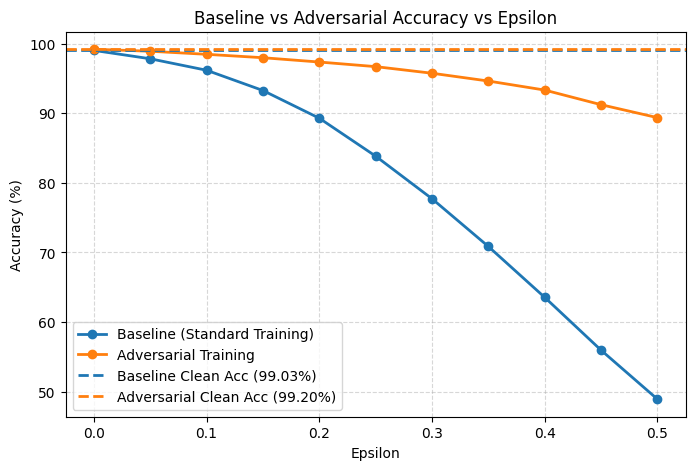

In [17]:
# Run adversarial training
net = Net()
adversarial_results = train(net, adversarial_training=True, alpha=0.5, epsilon_training=0.25, num_epochs=15, lr=0.001)

plot_adversarial_training(standard_results, adversarial_results)

## Test with Maxout network

standard training

Python executable: d:\UofW\CS679\project\.venv\Scripts\python.exe
PyTorch version: 2.4.1+cpu
CUDA available: False
DirectML available: True
Device: privateuseone:0 (directml)
Standard Training Started
Epoch 1/15 | Loss: 0.2147 | Test Acc: 97.81%
Epoch 2/15 | Loss: 0.0618 | Test Acc: 98.36%
Epoch 3/15 | Loss: 0.0478 | Test Acc: 98.57%
Epoch 4/15 | Loss: 0.0381 | Test Acc: 98.25%
Epoch 5/15 | Loss: 0.0312 | Test Acc: 98.78%
Epoch 6/15 | Loss: 0.0282 | Test Acc: 98.74%
Epoch 7/15 | Loss: 0.0227 | Test Acc: 98.70%
Epoch 8/15 | Loss: 0.0197 | Test Acc: 98.87%
Epoch 9/15 | Loss: 0.0185 | Test Acc: 98.68%
Epoch 10/15 | Loss: 0.0171 | Test Acc: 98.93%
Epoch 11/15 | Loss: 0.0153 | Test Acc: 98.82%
Epoch 12/15 | Loss: 0.0128 | Test Acc: 98.62%
Epoch 13/15 | Loss: 0.0137 | Test Acc: 98.89%
Epoch 14/15 | Loss: 0.0098 | Test Acc: 98.94%
Epoch 15/15 | Loss: 0.0109 | Test Acc: 98.79%
Test with adversarial examples:
Epsilon: 0.00 | FGSM Test Acc: 98.79%
Epsilon: 0.05 | FGSM Test Acc: 97.23%
Epsilon: 0

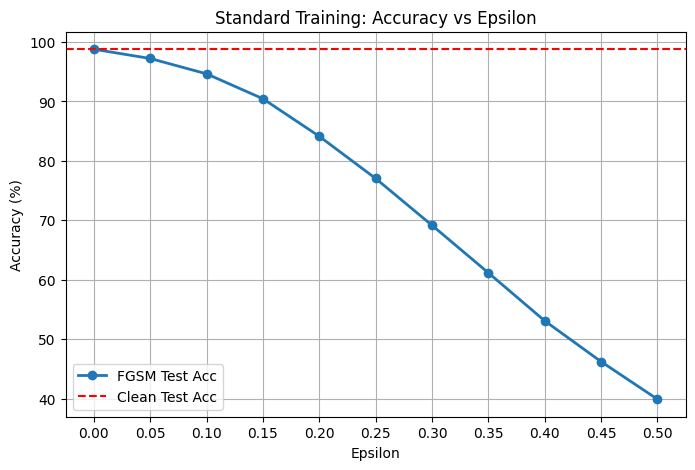

In [18]:
# Run standard training
net = MaxoutNet()
standard_results = train(net, adversarial_training=False, alpha=0.5, epsilon_training=0.25, num_epochs=15, lr=0.001)
plot_standard_training(standard_results)

adversarial training

Python executable: d:\UofW\CS679\project\.venv\Scripts\python.exe
PyTorch version: 2.4.1+cpu
CUDA available: False
DirectML available: True
Device: privateuseone:0 (directml)
Adversarial Training Started
Epoch 1/15 | Loss: 0.3364 | Test Acc: 98.26%
Epoch 2/15 | Loss: 0.1251 | Test Acc: 98.68%
Epoch 3/15 | Loss: 0.0974 | Test Acc: 98.84%
Epoch 4/15 | Loss: 0.0821 | Test Acc: 98.93%
Epoch 5/15 | Loss: 0.0731 | Test Acc: 99.06%
Epoch 6/15 | Loss: 0.0657 | Test Acc: 99.02%
Epoch 7/15 | Loss: 0.0586 | Test Acc: 98.97%
Epoch 8/15 | Loss: 0.0541 | Test Acc: 99.18%
Epoch 9/15 | Loss: 0.0500 | Test Acc: 99.12%
Epoch 10/15 | Loss: 0.0464 | Test Acc: 99.14%
Epoch 11/15 | Loss: 0.0443 | Test Acc: 99.07%
Epoch 12/15 | Loss: 0.0403 | Test Acc: 99.14%
Epoch 13/15 | Loss: 0.0380 | Test Acc: 99.12%
Epoch 14/15 | Loss: 0.0351 | Test Acc: 99.25%
Epoch 15/15 | Loss: 0.0332 | Test Acc: 99.14%
Test with adversarial examples:
Epsilon: 0.00 | FGSM Test Acc: 99.14%
Epsilon: 0.05 | FGSM Test Acc: 98.76%
Epsilon

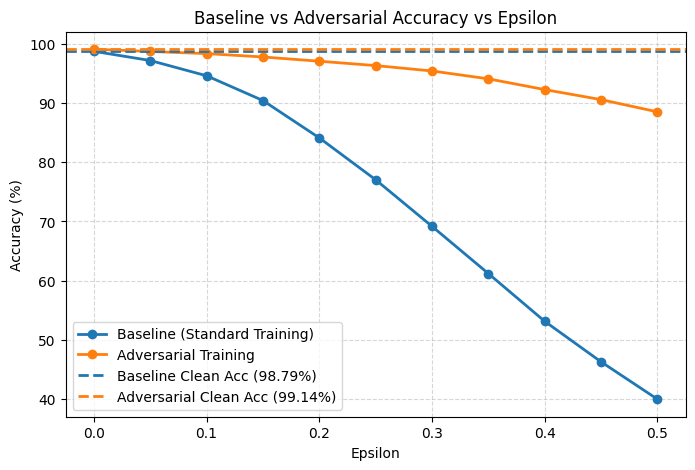

In [19]:
# Run adversarial training
net = MaxoutNet()
adversarial_results = train(net, adversarial_training=True, alpha=0.5, epsilon_training=0.25, num_epochs=15, lr=0.001)

plot_adversarial_training(standard_results, adversarial_results)